In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from pathlib import Path

In [42]:
# Paths — edit these to point to your CSV files
CROSS_CSV  = "../data/raw/final_dataset_1.csv"   # 50,000 cross-lingual rows
SAME_CSV   = "../data/raw/final_dataset.csv"     # 15,662 same-language rows
OUT_DIR    = Path("../data")
CLEAN_CSV  = OUT_DIR / "processed" / "combined_clean.csv"

(OUT_DIR / "processed").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "reports").mkdir(parents=True, exist_ok=True)

#### Load Dataset

In [43]:
df_cross = pd.read_csv(CROSS_CSV, low_memory=False)
df_same  = pd.read_csv(SAME_CSV,  low_memory=False)

df_cross.columns = [c.strip() for c in df_cross.columns]
df_same.columns  = [c.strip() for c in df_same.columns]

df_cross["dataset_source"] = "cross_lang"
df_same["dataset_source"]  = "same_lang"

print(f"Cross-lingual : {len(df_cross):,} rows  |  {df_cross.shape[1]} columns")
print(f"Same-language : {len(df_same):,} rows  |  {df_same.shape[1]} columns")

Cross-lingual : 50,000 rows  |  21 columns
Same-language : 15,662 rows  |  21 columns


In [44]:
print("Same-lingual (df_same)")
print(f"Columns: {df_same.columns.tolist()}")
df_same.head(3)

Same-lingual (df_same)
Columns: ['pair_id', 'annotator_id', 'language', 'lang1', 'lang2', 'text_a', 'text_b', 'text_source', 'link1', 'link2', 'content_similarity', 'GEO', 'ENT', 'TIME', 'NAR', 'OVERALL', 'STYLE', 'TONE', 'FRAME', 'source_file', 'dataset_source']


,pair_id,annotator_id,language,lang1,lang2,text_a,text_b,text_source,link1,link2,...,GEO,ENT,TIME,NAR,OVERALL,STYLE,TONE,FRAME,source_file,dataset_source
0,1636790850_1634135133,NaN,zh,zh,zh,法国医护人员在巴黎示威游行万余人参加,示威者在巴黎共和广场抗议种族歧视,title_only,http://www.chinanews.com/tp/hd2011/2020/06-17/...,http://www.chinanews.com/tp/hd2011/2020/06-14/...,...,4.0,3.0,4.0,3.0,3.0,4.0,4.0,2.0,zenodo_release_data_2024.csv,same_lang
1,1604224633_1554313283,NaN,de,de,de,„Der schwerste Kampf in meinem Leben“: Ministe...,Schwesig: Noch immer Touristen in Mecklenburg-...,title_only,https://www.mopo.de/im-norden/mecklenburg-vorp...,https://www.prignitzer.de/regionales/newsticke...,...,2.5,2.5,2.5,2.5,2.5,2.5,2.5,NaN,zenodo_release_data_2024.csv,same_lang
2,1630418022_1496780166,NaN,ar,ar,ar,مصر- بدء المرحلة الأولى من البرنامج التدريبى ...,خالد الجندى عن قاعدة برنيس: «أعداء الوطن حالته...,title_only,https://menafn.com/arabic/1100296979/مصر-بدء-ا...,http://www.almasryalyoum.com/news/details/1462295,...,4.0,1.0,1.0,1.0,1.0,4.0,4.0,NaN,zenodo_release_data_2024.csv,same_lang


In [45]:
print(" Cross-lingual (df_cross)")
print(f"Columns: {df_cross.columns.tolist()}")
df_cross.head(3)

 Cross-lingual (df_cross)
Columns: ['pair_id', 'annotator_id', 'language', 'lang1', 'lang2', 'text_a', 'text_b', 'text_source', 'link1', 'link2', 'content_similarity', 'GEO', 'ENT', 'TIME', 'NAR', 'OVERALL', 'STYLE', 'TONE', 'FRAME', 'source_file', 'dataset_source']


,pair_id,annotator_id,language,lang1,lang2,text_a,text_b,text_source,link1,link2,...,GEO,ENT,TIME,NAR,OVERALL,STYLE,TONE,FRAME,source_file,dataset_source
0,1776370964_1580358408,NaN,es-en,es,en,Coronavirus: Pandemia La gripe española de 191...,WHO European director urges caution on easing ...,title_only,https://www.madrimasd.org/blogs/ciencia_marina...,http://www.nationnews.com/nationnews/news/2450...,...,2.0,1.0,2.0,1.0,1.0,3.0,3.0,NaN,zenodo_release_data_2024.csv,cross_lang
1,1504938448_1504877206,NaN,de-en,de,en,Konflikte: Israel reagiert mit Luftangriffen a...,Israel strikes in Gaza in response to incendia...,title_only,https://www.braunschweiger-zeitung.de/politik/...,https://www.nst.com.my/world/world/2020/01/559...,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,NaN,zenodo_release_data_2024.csv,cross_lang
2,1564217220_1531933920,NaN,de-fr,de,fr,Corona-Virus: Apple-Mitarbeiter bekommen Care-...,Coronavirus : Foxconn proposerait des primes p...,title_only,https://www.macwelt.de/news/Corona-Virus-Apple...,https://www.numerama.com/business/608070-coron...,...,2.5,2.5,2.5,2.5,2.5,2.5,2.5,NaN,zenodo_release_data_2024.csv,cross_lang


In [46]:
print(f" Same language :") 
print("-" * 80)
df_same.describe()

 Same language :
--------------------------------------------------------------------------------


,content_similarity,GEO,ENT,TIME,NAR,OVERALL,STYLE,TONE,FRAME
count,15650.000000,15662.00000,15662.000000,15662.000000,15662.000000,15662.000000,15662.000000,15662.000000,2311.000000
mean,0.370953,3.32084,2.740965,3.143596,2.493775,2.526242,3.353052,3.354074,3.131977
std,0.180645,0.92978,1.094786,1.061139,1.111903,1.094425,0.849886,0.853623,0.831013
min,0.023675,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.239130,2.50000,2.000000,2.500000,1.000000,2.000000,2.500000,2.500000,2.500000
50%,0.354167,4.00000,3.000000,4.000000,2.500000,2.500000,4.000000,4.000000,3.000000
75%,0.454545,4.00000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000
max,1.000000,4.00000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


In [47]:
print(f" Cross-lingual :")
print("-" * 80)
df_cross.describe()

 Cross-lingual :
--------------------------------------------------------------------------------


,annotator_id,content_similarity,GEO,ENT,TIME,NAR,OVERALL,STYLE,TONE,FRAME
count,0.0,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,204.000000
mean,NaN,0.371547,3.025450,2.579240,2.83849,2.357740,2.401340,3.025140,3.031620,3.455882
std,NaN,0.149249,0.990842,1.023363,1.07288,1.039882,1.026614,0.909733,0.864052,0.728055
min,NaN,0.200000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,NaN,0.250000,2.500000,2.000000,2.00000,1.000000,1.000000,2.500000,2.500000,2.875000
50%,NaN,0.333333,3.000000,2.500000,2.50000,2.500000,2.500000,3.000000,3.000000,4.000000
75%,NaN,0.454545,4.000000,3.000000,4.00000,3.000000,3.000000,4.000000,4.000000,4.000000
max,NaN,1.000000,4.000000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,4.000000


Text(0.5, 1.0, 'Distribution of Languages in Same-language Dataset')

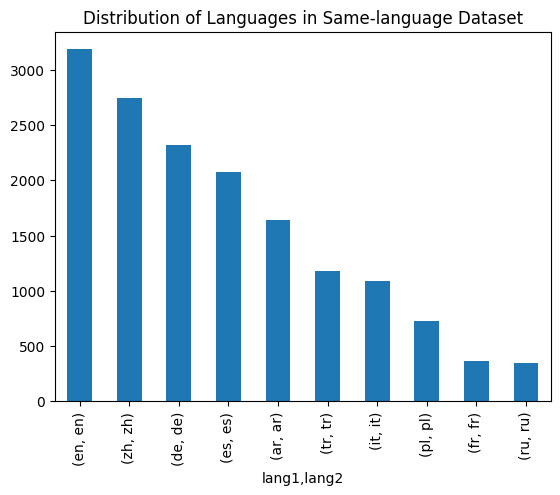

In [48]:
df_same[['lang1','lang2']].value_counts().plot(kind='bar')
plt.title('Distribution of Languages in Same-language Dataset')

Text(0.5, 1.0, 'Distribution of Language Pairs in Cross-lingual Dataset')

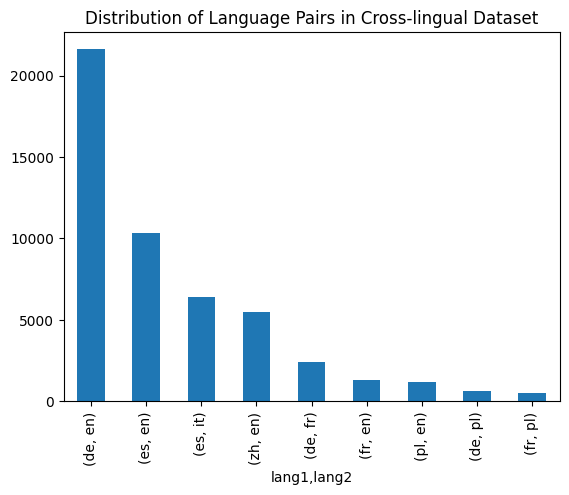

In [49]:
df_cross[['lang1', 'lang2']].value_counts().plot(kind='bar')
plt.title('Distribution of Language Pairs in Cross-lingual Dataset')

In [50]:
# Check OVERALL unique values — confirms the scale
print("Cross-lang OVERALL unique values (sample):")
print(sorted(df_cross["OVERALL"].dropna().unique())[:20])
print(f"  min={df_cross['OVERALL'].dropna().min()}  max={df_cross['OVERALL'].dropna().max()}")
print()
print("Same-lang OVERALL unique values (sample):")
print(sorted(df_same["OVERALL"].dropna().unique())[:20])
print(f"  min={df_same['OVERALL'].dropna().min()}  max={df_same['OVERALL'].dropna().max()}")

Cross-lang OVERALL unique values (sample):
[np.float64(1.0), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(4.0)]
  min=1.0  max=4.0

Same-lang OVERALL unique values (sample):
[np.float64(1.0), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(4.0)]
  min=1.0  max=4.0


#### Merge Both data

In [51]:
df_raw = pd.concat([df_cross, df_same], ignore_index=True)
print(f"Combined raw : {len(df_raw):,} rows  |  {df_raw.shape[1]} columns")
print(f"  Columns       : {df_raw.columns.tolist()}")
df_raw.describe()

Combined raw : 65,662 rows  |  21 columns
  Columns       : ['pair_id', 'annotator_id', 'language', 'lang1', 'lang2', 'text_a', 'text_b', 'text_source', 'link1', 'link2', 'content_similarity', 'GEO', 'ENT', 'TIME', 'NAR', 'OVERALL', 'STYLE', 'TONE', 'FRAME', 'source_file', 'dataset_source']


,content_similarity,GEO,ENT,TIME,NAR,OVERALL,STYLE,TONE,FRAME
count,65650.000000,65662.000000,65662.000000,65662.000000,65662.000000,65662.000000,65662.000000,65662.000000,2515.00000
mean,0.371405,3.095908,2.617815,2.911265,2.390188,2.431132,3.103355,3.108533,3.15825
std,0.157302,0.984697,1.043116,1.077955,1.059085,1.044538,0.906650,0.872460,0.82775
min,0.023675,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000
25%,0.250000,2.500000,2.000000,2.500000,1.000000,1.000000,2.500000,2.500000,2.50000
50%,0.333333,3.000000,2.500000,2.500000,2.500000,2.500000,3.000000,3.000000,3.00000
75%,0.454545,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,4.00000
max,1.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000


In [52]:
# data type overview
print(df_raw.dtypes.to_string())

pair_id                   str
annotator_id           object
language                  str
lang1                     str
lang2                     str
text_a                    str
text_b                    str
text_source               str
link1                     str
link2                     str
content_similarity    float64
GEO                   float64
ENT                   float64
TIME                  float64
NAR                   float64
OVERALL               float64
STYLE                 float64
TONE                  float64
FRAME                 float64
source_file               str
dataset_source            str


In [53]:
# missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
missing_df[missing_df.missing_count > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_%
annotator_id,65650,100.0
FRAME,63147,96.2
content_similarity,12,0.0


In [54]:
print("text_source (should all be title_only)")
print(df_raw["text_source"].value_counts().to_string())

print("\ndataset_source breakdown")
print(df_raw["dataset_source"].value_counts().to_string())

text_source (should all be title_only)
text_source
title_only      65646
article_json       16

dataset_source breakdown
dataset_source
cross_lang    50000
same_lang     15662


#### Data Cleaning

In [55]:
df = df_raw.copy()
n_start = len(df)
audit   = {}

print(f"Starting with {n_start:,} rows")

Starting with 65,662 rows


In [56]:
# ── Step 1: Deduplicate by (text_a, text_b) — the only thing that matters ──
#   • The same article headline can appear under multiple pair_ids
#     if it was annotated by different annotators or pulled from
#     different Zenodo CSV files.
#   • For NLI training, what the model sees is (text_a, text_b).
#     Two rows with the same text but different pair_ids are
#     identical training examples — keeping both leaks into val/test.
#
# Strategy:
#   1. Normalise both texts first (strip whitespace, lowercase)
#      so "WHO declares pandemic" == "who declares pandemic"
#   2. Keep the first occurrence (default pandas behaviour)
#   3. Report how many were removed

before = len(df)

# Normalise for comparison only (don't overwrite original text)
df["_text_a_norm"] = df["text_a"].str.strip().str.lower()
df["_text_b_norm"] = df["text_b"].str.strip().str.lower()

# Also deduplicate the reverse direction:
# (article A, article B) and (article B, article A) are the same pair
# Create a canonical key: always sort the two texts alphabetically
df["_dedup_key"] = df.apply(
    lambda r: tuple(sorted([r["_text_a_norm"], r["_text_b_norm"]])),
    axis=1
)

df = df.drop_duplicates(subset=["_dedup_key"]).reset_index(drop=True)
df = df.drop(columns=["_text_a_norm", "_text_b_norm", "_dedup_key"])

audit["1_dedup"] = before - len(df)
print(f"Step 1 dedup (text_a+text_b) : removed {audit['1_dedup']:,}  |  remaining {len(df):,}")
print(f"  (Removed exact text duplicates AND reversed-order duplicates)")

Step 1 dedup (text_a+text_b) : removed 46,473  |  remaining 19,189
  (Removed exact text duplicates AND reversed-order duplicates)


In [57]:
def word_score_to_float(cell):
    """Handle word-form scores from per-annotator files."""
    MAP = {
        "Very Dissimilar": 1.0, "Somewhat Dissimilar": 2.0,
        "Other": 2.5, "Somewhat Similar": 3.0,
        "Very Similar": 4.0, "": None,
    }
    cell = str(cell or "").strip()
    if cell in MAP:
        return MAP[cell]
    try:
        return float(cell)
    except ValueError:
        return None

In [58]:
# Step 2: Normalise score columns
# Converts word-form labels ("Very Similar" → 4.0) to floats
SCORE_COLS_ALL = ["GEO","ENT","TIME","NAR","OVERALL","STYLE","TONE","FRAME"]
for col in SCORE_COLS_ALL:
    if col in df.columns:
        df[col] = df[col].apply(word_score_to_float)

df["OVERALL"] = pd.to_numeric(df["OVERALL"], errors="coerce")
print("Step 2 score normalise: done)")
print(f"  OVERALL min={df['OVERALL'].min():.2f}  max={df['OVERALL'].max():.2f}")

Step 2 score normalise: done)
  OVERALL min=1.00  max=4.00


In [59]:
# NLI thresholds (1-4 scale_
ENTAILMENT_MIN    = 4.0   # OVERALL >= 4.0
NEUTRAL_MIN       = 2.0   # OVERALL 2.0 – 3.9
CONTRADICTION_MAX = 1.9  # OVERALL <= 1.9

# Convert OVERALL similarity score (1–4) to NLI label string
def score_to_nli(score):
    try:
        s = float(score)
    except (TypeError, ValueError):
        return None
    if   s >= ENTAILMENT_MIN:    return "ENTAILMENT"
    elif s >= NEUTRAL_MIN:       return "NEUTRAL"
    elif s <= CONTRADICTION_MAX: return "CONTRADICTION"
    return None

In [60]:
# Step 3: Apply NLI labels
df["nli_label"] = df["OVERALL"].apply(score_to_nli)

# Only drop rows with missing/non-numeric OVERALL — no gap zone anymore
before = len(df)
df = df.dropna(subset=["nli_label"]).reset_index(drop=True)
audit["3_missing_score"] = before - len(df)

print(f"Step 3 NLI labels : removed {audit['3_missing_score']:,} (missing OVERALL only)")

Step 3 NLI labels : removed 0 (missing OVERALL only)


In [61]:
# Step 4: Create lang_pair column
for col in ["lang1", "lang2", "language"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()

df["lang_pair"] = df["lang1"].fillna("?") + "-" + df["lang2"].fillna("?")
print("Step 4 lang_pair      : created")
print(f"  Unique pairs: {df['lang_pair'].nunique()}")
print(df["lang_pair"].value_counts().to_string())

Step 4 lang_pair      : created
  Unique pairs: 19
lang_pair
en-en    3146
zh-zh    2745
de-de    2298
es-es    2061
ar-ar    1645
de-en    1550
tr-tr    1177
it-it    1085
es-en     740
pl-pl     723
es-it     472
zh-en     398
fr-fr     363
ru-ru     343
de-fr     171
fr-en      98
pl-en      88
de-pl      46
fr-pl      40


In [22]:
df_counts = df["lang_pair"].value_counts().reset_index()
df_counts.columns = ['lang_pair', 'count']

fig = px.bar(
    df_counts, 
    x='count', 
    y='lang_pair', 
    orientation='h',
    title='Distribution of Language Pairs',
    color='count',   
    color_continuous_scale='Viridis'
)
fig.update_yaxes(autorange="reversed")
fig.show()

In [23]:
# Step 5: Coerce & clean text columns
df["text_a"] = df["text_a"].fillna("").astype(str).str.strip()
df["text_b"] = df["text_b"].fillna("").astype(str).str.strip()

before = len(df)
df = df[(df["text_a"].str.len() > 0) & (df["text_b"].str.len() > 0)].reset_index(drop=True)
audit["5_empty_text"] = before - len(df)
print(f"Step 5 empty text     : removed {audit['5_empty_text']:,}  |  remaining {len(df):,}")

Step 5 empty text     : removed 0  |  remaining 19,189


In [24]:
# Text quality 
MIN_CHARS = 15    # min headline length
MAX_CHARS = 500   # truncation cap

In [25]:
def is_junk_text(text):
    """Return True if text is JS/navigation junk rather than a news headline."""
    if not text or len(text.strip()) < MIN_CHARS:
        return True
    junk_markers = [
        "jquery", "drupal.settings", "window.location",
        "function(", "var ", "$(document)", "google.com/recaptcha",
        "addEventListener", "document.write",
    ]
    return any(m in text.lower() for m in junk_markers)

In [26]:
# Step 6: Remove junk / JS text 
before    = len(df)
is_junk   = df["text_a"].apply(is_junk_text) | df["text_b"].apply(is_junk_text)
df        = df[~is_junk].reset_index(drop=True)
audit["6_junk"] = before - len(df)
print(f"Step 6 junk text      : removed {audit['6_junk']:,}  |  remaining {len(df):,}")

Step 6 junk text      : removed 522  |  remaining 18,667


In [27]:
# Step 7: Drop too-short pairs (< 15 chars)
before    = len(df)
too_short = (df["text_a"].str.len() < MIN_CHARS) | (df["text_b"].str.len() < MIN_CHARS)
df        = df[~too_short].reset_index(drop=True)
audit["7_too_short"] = before - len(df)
print(f"Step 7 too short      : removed {audit['7_too_short']:,}  |  remaining {len(df):,}")

Step 7 too short      : removed 0  |  remaining 18,667


In [28]:
# Step 8: Truncate long texts (> 1500 chars) 
n_long = (df["text_a"].str.len() > MAX_CHARS).sum() + (df["text_b"].str.len() > MAX_CHARS).sum()
df["text_a"] = df["text_a"].str[:MAX_CHARS]
df["text_b"] = df["text_b"].str[:MAX_CHARS]
audit["8_truncated_fields"] = int(n_long)
print(f"Step 8 truncation     : clipped {n_long:,} fields (rows kept)")

Step 8 truncation     : clipped 8 fields (rows kept)


In [29]:
# ── Step 9: Drop columns not needed for training ─────────────────
# KEPT:  link1, link2  — used for outlet extraction below
# DROP:  FRAME (85-99% missing), STYLE/TONE (near-constant, low signal)
#        language/lang1/lang2 (redundant — lang_pair has same info)
#        content_similarity (data leakage)
#        text_source (constant "title_only"), source_file, dataset_source

DROP_COLS = [
    "FRAME", "STYLE", "TONE",
    "language", "lang1", "lang2",
    "text_source", "source_file",
    "content_similarity", "dataset_source", "annotator_id",
]

df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
audit["9_cols_dropped"] = len(DROP_COLS)
print(f"Step 9 drop columns   : {len(DROP_COLS)} columns dropped")
print(f"  NOTE: link1, link2 KEPT for outlet extraction")
print(f"  Remaining columns   : {df.columns.tolist()}")

Step 9 drop columns   : 11 columns dropped
  NOTE: link1, link2 KEPT for outlet extraction
  Remaining columns   : ['pair_id', 'text_a', 'text_b', 'link1', 'link2', 'GEO', 'ENT', 'TIME', 'NAR', 'OVERALL', 'nli_label', 'lang_pair']


In [30]:
from urllib.parse import urlparse

def extract_domain(url):
    try:
        host = urlparse(str(url or "")).netloc.lower().strip()
        if host.startswith("www."):
            host = host[4:]
        return host if host else "unknown"
    except:
        return "unknown"

df["outlet_a"] = df["link1"].apply(extract_domain)
df["outlet_b"] = df["link2"].apply(extract_domain)

Text(0.5, 1.0, 'Top 10 Outlets in text_a')

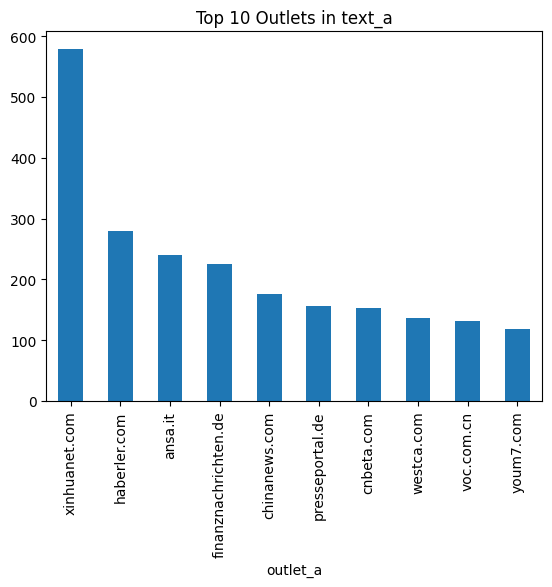

In [31]:
df['outlet_a'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Outlets in text_a')

Text(0.5, 1.0, 'Top 10 Outlets in text_b')

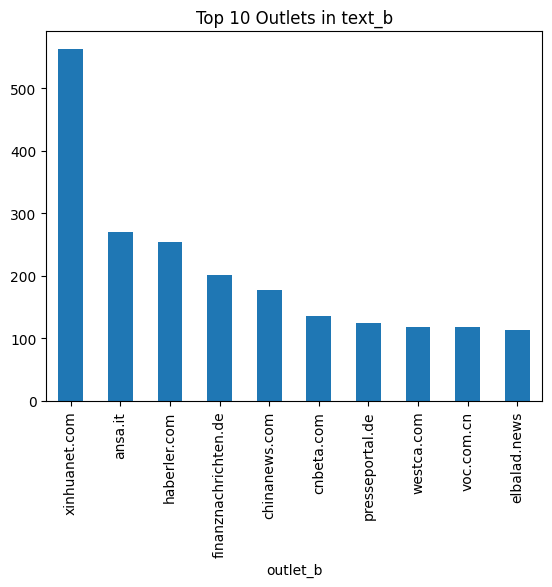

In [32]:
df['outlet_b'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Outlets in text_b')

In [33]:
df['outlet_pair'] = df.apply(
    lambda r: tuple(sorted([r["outlet_a"], r["outlet_b"]])),
    axis=1
)

In [34]:
# Step 10: Add label_id, helper length columns
df["label_id"] = df["nli_label"].map({"ENTAILMENT":0,"NEUTRAL":1,"CONTRADICTION":2})

# Keep length cols only for EDA — dropped before model training
df["text_a_len"]   = df["text_a"].str.len()
df["text_b_len"]   = df["text_b"].str.len()
df["text_a_words"] = df["text_a"].str.split().str.len()
df["combined_tok"] = ((df["text_a_words"] + df["text_b"].str.split().str.len()) / 0.75).astype(int)

print("Step 10 helpers       : label_id, length columns added")
print(f"Final columns         : {df.columns.tolist()}")

Step 10 helpers       : label_id, length columns added
Final columns         : ['pair_id', 'text_a', 'text_b', 'link1', 'link2', 'GEO', 'ENT', 'TIME', 'NAR', 'OVERALL', 'nli_label', 'lang_pair', 'outlet_a', 'outlet_b', 'outlet_pair', 'label_id', 'text_a_len', 'text_b_len', 'text_a_words', 'combined_tok']


In [35]:
df['nli_label'].value_counts()

nli_label
NEUTRAL          9658
CONTRADICTION    4584
ENTAILMENT       4425
Name: count, dtype: int64

#### Cleaning Audit Summary

In [36]:
n_end         = len(df)
total_dropped = n_start - n_end

print("=" * 52)
print("CLEANING AUDIT")
print("=" * 52)
print(f"  Started with   : {n_start:>8,}")
for step, count in audit.items():
    print(f"  {step:<26}: {count:>8,}")
print(f"  {'':─<40}")
print(f"  Total dropped  : {total_dropped:>8,}  ({total_dropped/n_start*100:.1f}%)")
print(f"  Clean dataset  : {n_end:>8,}")
print("=" * 52)

print("\nNLI label distribution (clean):")
for lbl, cnt in df["nli_label"].value_counts().items():
    bar = "█" * int(cnt / n_end * 40)
    print(f"  {lbl:15}: {cnt:>6,}  ({cnt/n_end:.1%})  {bar}")

CLEANING AUDIT
  Started with   :   65,662
  1_dedup                   :   46,473
  3_missing_score           :        0
  5_empty_text              :        0
  6_junk                    :      522
  7_too_short               :        0
  8_truncated_fields        :        8
  9_cols_dropped            :       11
  ────────────────────────────────────────
  Total dropped  :   46,995  (71.6%)
  Clean dataset  :   18,667

NLI label distribution (clean):
  NEUTRAL        :  9,658  (51.7%)  ████████████████████
  CONTRADICTION  :  4,584  (24.6%)  █████████
  ENTAILMENT     :  4,425  (23.7%)  █████████


In [37]:
df.columns

Index(['pair_id', 'text_a', 'text_b', 'link1', 'link2', 'GEO', 'ENT', 'TIME',
       'NAR', 'OVERALL', 'nli_label', 'lang_pair', 'outlet_a', 'outlet_b',
       'outlet_pair', 'label_id', 'text_a_len', 'text_b_len', 'text_a_words',
       'combined_tok'],
      dtype='str')

In [39]:
# Columns for the saved clean CSV
# Includes outlet columns + helper length cols for EDA notebook
SAVE_COLS_EXTENDED = [
    "pair_id", "lang_pair",
    "link1", "link2",                                    # raw URLs (for Media Bias Matrix)
    "outlet_a", "outlet_b",                              # outlet names
    "outlet_pair",
    "text_a", "text_b",                                  # article texts
    "OVERALL", "GEO", "ENT", "TIME", "NAR",             # similarity scores
    "nli_label", "label_id",                             # NLI target
    "text_a_len", "text_b_len", "text_a_words", "combined_tok",  # EDA helpers
]

df_save = df[[c for c in SAVE_COLS_EXTENDED if c in df.columns]]

from pathlib import Path
Path("../data/processed").mkdir(parents=True, exist_ok=True)
df_save.to_csv(CLEAN_CSV, index=False, encoding="utf-8-sig")

print(f"Saved: {CLEAN_CSV}")
print(f"Shape: {df_save.shape}")
print(f"Columns ({len(df_save.columns)}): {df_save.columns.tolist()}")
print()
df_save.head(3)

Saved: ..\data\processed\combined_clean.csv
Shape: (18667, 20)
Columns (20): ['pair_id', 'lang_pair', 'link1', 'link2', 'outlet_a', 'outlet_b', 'outlet_pair', 'text_a', 'text_b', 'OVERALL', 'GEO', 'ENT', 'TIME', 'NAR', 'nli_label', 'label_id', 'text_a_len', 'text_b_len', 'text_a_words', 'combined_tok']



,pair_id,lang_pair,link1,link2,outlet_a,outlet_b,outlet_pair,text_a,text_b,OVERALL,GEO,ENT,TIME,NAR,nli_label,label_id,text_a_len,text_b_len,text_a_words,combined_tok
0,1776370964_1580358408,es-en,https://www.madrimasd.org/blogs/ciencia_marina...,http://www.nationnews.com/nationnews/news/2450...,madrimasd.org,nationnews.com,"(madrimasd.org, nationnews.com)",Coronavirus: Pandemia La gripe española de 191...,WHO European director urges caution on easing ...,1.0,2.0,1.0,2.0,1.0,CONTRADICTION,2,113,55,19,36
1,1504938448_1504877206,de-en,https://www.braunschweiger-zeitung.de/politik/...,https://www.nst.com.my/world/world/2020/01/559...,braunschweiger-zeitung.de,nst.com.my,"(braunschweiger-zeitung.de, nst.com.my)",Konflikte: Israel reagiert mit Luftangriffen a...,Israel strikes in Gaza in response to incendia...,4.0,4.0,4.0,4.0,4.0,ENTAILMENT,0,68,57,7,21
2,1564217220_1531933920,de-fr,https://www.macwelt.de/news/Corona-Virus-Apple...,https://www.numerama.com/business/608070-coron...,macwelt.de,numerama.com,"(macwelt.de, numerama.com)",Corona-Virus: Apple-Mitarbeiter bekommen Care-...,Coronavirus : Foxconn proposerait des primes p...,2.5,2.5,2.5,2.5,2.5,NEUTRAL,1,62,85,6,24
